In [1]:
import sqlite3
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
conn = sqlite3.connect("/Users/nhatynhi/Documents/chocolate.db")

In [5]:
# Check available tables
df_tables = pd.read_sql_query("""
SELECT name FROM sqlite_master WHERE type='table';
""", conn)

print(df_tables)

            name
0       calendar
1      customers
2       products
3          sales
4         stores
5      chocolate
6  monthly_sales


In [6]:
# Load monthly sales data
df = pd.read_sql_query("""
SELECT * FROM monthly_sales
ORDER BY year, month
""", conn)
print(df.head())

   year  month  monthly_revenue  monthly_quantity  monthly_profit
0  2023      1       1095019.20            128486       438230.77
1  2023      2        968948.95            114154       387259.34
2  2023      3       1084656.09            127279       433765.09
3  2023      4       1038425.32            122274       415827.16
4  2023      5       1083418.79            127781       433491.77


21:49:25 - cmdstanpy - INFO - Chain [1] start processing
21:49:25 - cmdstanpy - INFO - Chain [1] done processing


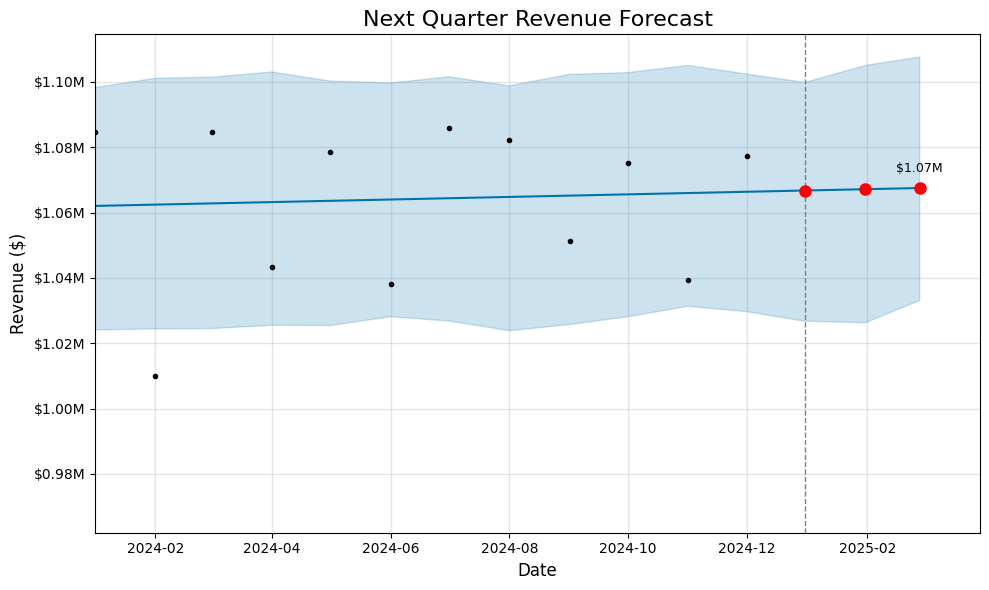

In [8]:
# FORECAST REVENUE
df["ds"] = pd.to_datetime(df[["year","month"]].assign(day=1))
df_rev = df[["ds","monthly_revenue"]].rename(columns={"monthly_revenue": "y"})

# Train model
model = Prophet()
model.fit(df_rev)

# Create future dates
future = model.make_future_dataframe(periods=3, freq='ME')

# Predict
forecast = model.predict(future)

# Plot
fig = model.plot(forecast)

ax = fig.gca()

import pandas as pd

# Limit x-axis
ax.set_xlim(
    pd.to_datetime('2024-01-01'),
    pd.to_datetime('2025-03-31')
)

# Title
ax.set_title("Next Quarter Revenue Forecast", fontsize=16)

# Axis labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Revenue ($)", fontsize=12)

# Format y-axis as millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e6:.2f}M')
)

# Add forecast start line
forecast_start = future.iloc[-3]["ds"]

ax.axvline(
    x=forecast_start,
    color='gray',
    linestyle='--',
    linewidth=1
)

# Get last 3 forecasted months
future_forecast = forecast.tail(3)

# Add markers on top of forecast line
ax.plot(
    future_forecast['ds'],
    future_forecast['yhat'],
    'o',
    color='red',
    markersize=8,
    zorder=10
)

#Label
last_forecast = future_forecast.iloc[-1]
ax.text(
    last_forecast['ds'],
    last_forecast['yhat'] + 5000,  # move label upward
    f"${last_forecast['yhat']/1e6:.2f}M",
    fontsize=9,
    ha='center'
)
plt.tight_layout()
plt.show()

In [9]:
# Forecast revenue for next 3 months
future_forecast = forecast.tail(3)

total_forecast_revenue = future_forecast['yhat'].sum()
print(f"Predicted Revenue for Next 3 Months: ${total_forecast_revenue:,.2f}")

Predicted Revenue for Next 3 Months: $3,201,443.94


21:49:56 - cmdstanpy - INFO - Chain [1] start processing
21:49:56 - cmdstanpy - INFO - Chain [1] done processing


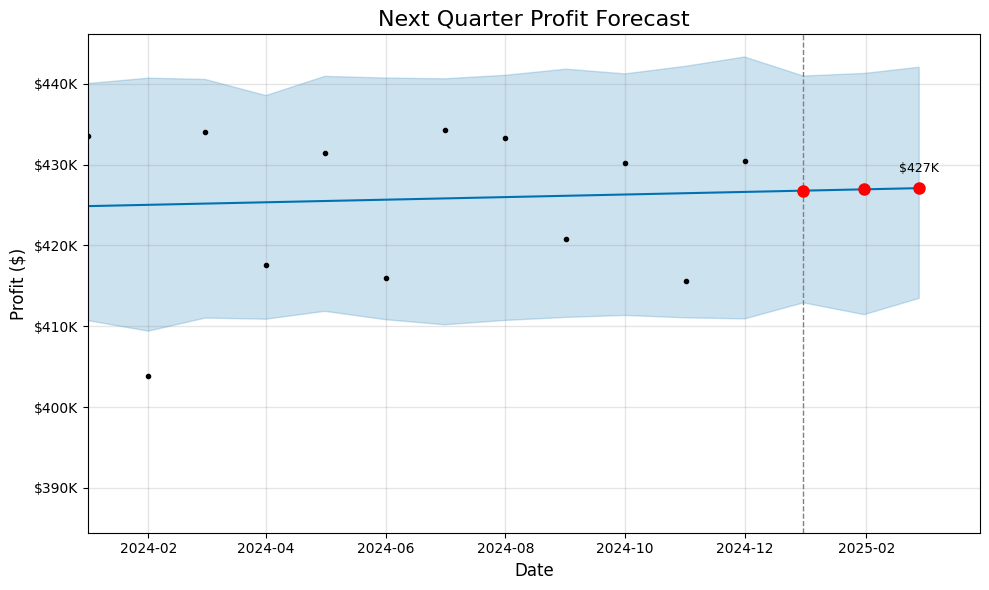

In [10]:
# FORECAST PROFIT
df["ds"] = pd.to_datetime(df[["year","month"]].assign(day=1))
df_profit = df[["ds","monthly_profit"]].rename(columns={"monthly_profit":"y"})

# Train model
model_profit = Prophet()
model_profit.fit(df_profit)

# Create future dates
future = model_profit.make_future_dataframe(periods=3, freq='ME')

# Predict
forecast_profit = model_profit.predict(future)

# Plot
fig = model_profit.plot(forecast_profit)

ax = fig.gca()

import pandas as pd

# Limit x-axis
ax.set_xlim(
    pd.to_datetime('2024-01-01'),
    pd.to_datetime('2025-03-31')
)

# Title
ax.set_title("Next Quarter Profit Forecast", fontsize=16)

# Axis labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Profit ($)", fontsize=12)

# Format y-axis as millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'${x/1e3:.0f}K')
)

# Add forecast start line
forecast_start = future.iloc[-3]["ds"]

ax.axvline(
    x=forecast_start,
    color='gray',
    linestyle='--',
    linewidth=1
)

# Get last 3 forecasted months
future_forecast = forecast_profit.tail(3)

# Add markers on top of forecast line
ax.plot(
    future_forecast['ds'],
    future_forecast['yhat'],
    'o',
    color='red',
    markersize=8,
    zorder=10
)

#Label
last_forecast = future_forecast.iloc[-1]

ax.text(
    last_forecast['ds'],
    last_forecast['yhat'] + 2000,  # move label upward
    f"${last_forecast['yhat']/1e3:.0f}K",
    fontsize=9,
    ha='center'
)
plt.tight_layout()
plt.show()

In [11]:
# Forecast profit for next 3 months
future_forecast = forecast_profit.tail(3)

total_forecast_profit = future_forecast['yhat'].sum()
print(f"Predicted Profit for Next 3 Months: ${total_forecast_profit:,.2f}")

Predicted Profit for Next 3 Months: $1,280,798.17


21:50:20 - cmdstanpy - INFO - Chain [1] start processing
21:50:20 - cmdstanpy - INFO - Chain [1] done processing


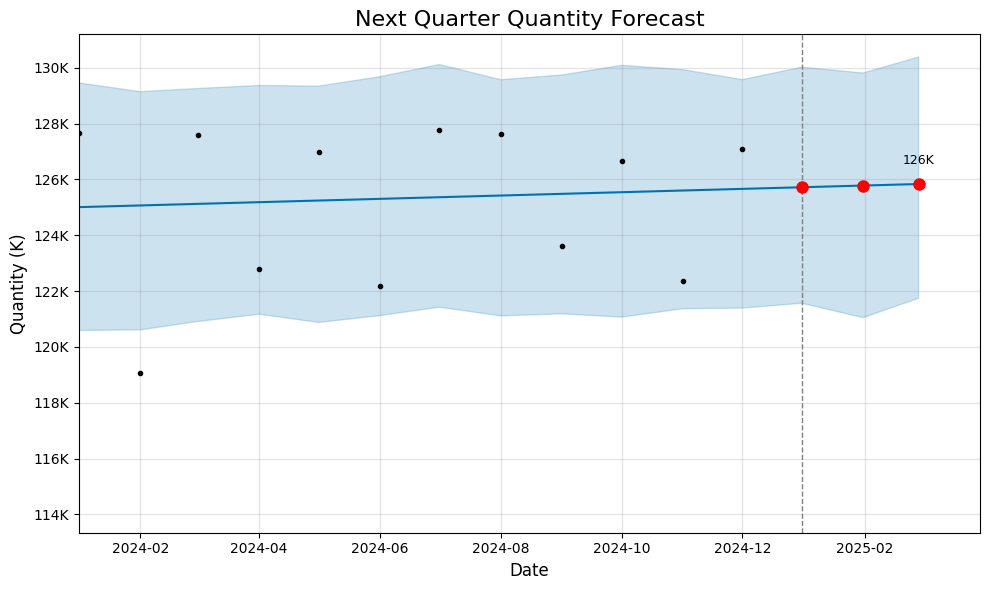

In [12]:
# FORECAST QUANTITY
df["ds"] = pd.to_datetime(df[["year","month"]].assign(day=1))
df_qty = df[["ds","monthly_quantity"]].rename(columns={"monthly_quantity":"y"})

# Train model
model_qty = Prophet()
model_qty.fit(df_qty)

# Create future dates
future = model_qty.make_future_dataframe(periods=3, freq='ME')

# Predict
forecast_qty = model_qty.predict(future)

# Plot
fig = model_qty.plot(forecast_qty)

ax = fig.gca()

import pandas as pd

# Limit x-axis
ax.set_xlim(
    pd.to_datetime('2024-01-01'),
    pd.to_datetime('2025-03-31')
)

# Title
ax.set_title("Next Quarter Quantity Forecast", fontsize=16)

# Axis labels
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Quantity (K)", fontsize=12)

# Format y-axis as millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e3:.0f}K')
)

# Add forecast start line
forecast_start = future.iloc[-3]["ds"]

ax.axvline(
    x=forecast_start,
    color='gray',
    linestyle='--',
    linewidth=1
)

# Get last 3 forecasted months
future_forecast = forecast_qty.tail(3)

# Add markers on top of forecast line
ax.plot(
    future_forecast['ds'],
    future_forecast['yhat'],
    'o',
    color='red',
    markersize=8,
    zorder=10
)

#Label
last_forecast = future_forecast.iloc[-1]

ax.text(
    last_forecast['ds'],
    last_forecast['yhat'] + 700,  # move label upward
    f"{last_forecast['yhat']/1e3:.0f}K",
    fontsize=9,
    ha='center'
)
plt.tight_layout()
plt.show()

In [28]:
# Forecast Quantity for next 3 months
future_forecast = forecast_qty.tail(3)

total_forecast_quantity = future_forecast['yhat'].sum()
print(f"Predicted Quantity for Next 3 Months: {total_forecast_quantity:,.0f}")

Predicted Quantity for Next 3 Months: 377,341
